# Imports Libraries

In [16]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import os
import pickle
import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [17]:
# df = pd.read_csv(
#     r"C:\Users\hp\Documents\ClimateGuardAI\datasets\engineered\climate_risk_scored_output.csv"
# )
df = pd.read_csv(
    r"D:\ClimateGuardAI\datasets\engineered\climate_risk_scored_output.csv"
)


features = [
    'temperature_celsius',
    'humidity',
    'pressure_mb',
    'cloud',
    'wind_kph',
    'visibility_km',
    'air_quality_PM2.5',
    'air_quality_PM10'
]

X = df[features]
y = df['rainfall_risk']

# Train-Test Split

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model

In [19]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# SHAP Explainer

In [20]:
explainer = shap.TreeExplainer(model)

# Save Explainer

In [21]:
# model_dir = r"C:\Users\hp\Documents\ClimateGuardAI\backend\ml\artifacts"
model_dir = r"D:\ClimateGuardAI\backend\ml\artifacts"

os.makedirs(model_dir, exist_ok=True)

with open(
    os.path.join(model_dir, "explainer.pkl"),
    "wb"
) as f:
    pickle.dump(explainer, f)

print("explainer.pkl saved successfully.")

explainer.pkl saved successfully.


# Use only 1000 samples for SHAP

In [22]:
X_test_small = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=42
)

shap_values = explainer.shap_values(X_test_small)

# Explain One Sample

In [23]:
sample = X_test.iloc[[0]]
prediction = model.predict(sample)

print("Prediction:", prediction[0])

single_shap = explainer.shap_values(sample)

# Get the index of the predicted class for 'sample'
predicted_class_idx = list(model.classes_).index(prediction[0])

Prediction: Medium


# Waterfall Plot

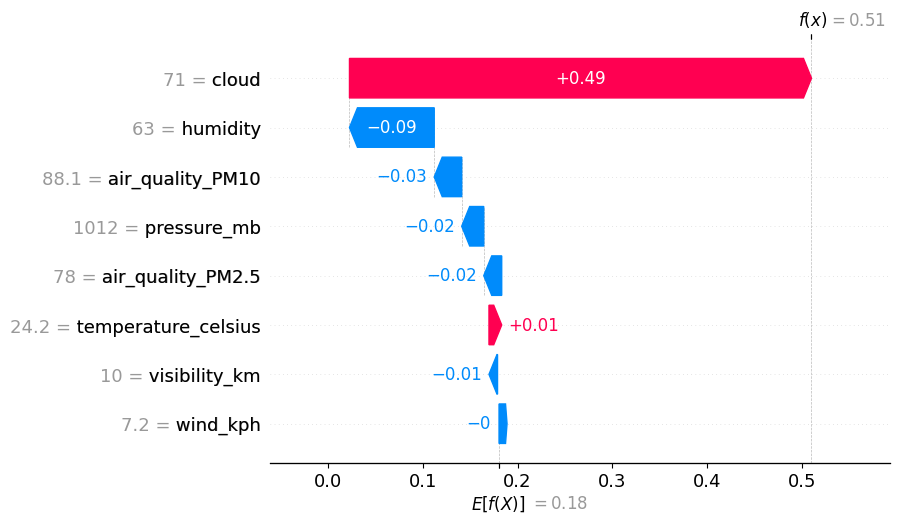

In [24]:
try:
    shap.plots.waterfall(
        shap.Explanation(
            values=single_shap[0, :, predicted_class_idx], # Corrected indexing for single sample and predicted class
            base_values=explainer.expected_value[predicted_class_idx], # Corrected indexing
            data=sample.iloc[0],
            feature_names=sample.columns
        )
    )
except Exception as e:
    print(f"Error generating waterfall plot: {e}")
    print("Waterfall plot not supported with this SHAP version or data structure.")

# Create Explanation Table

In [25]:
# Corrected to ensure contributions is a 1D array for the predicted class
contributions = single_shap[0, :, predicted_class_idx]

sample_shap = pd.DataFrame({
    'Feature': sample.columns,
    'Contribution': contributions
})

sample_shap = sample_shap.sort_values(
    by='Contribution',
    ascending=False
)

sample_shap['Direction'] = np.where(
    sample_shap['Contribution'] > 0,
    'Increase Risk',
    np.where(
        sample_shap['Contribution'] < 0,
        'Decrease Risk',
        'No Impact'
    )
)

sample_shap['Prediction'] = prediction[0]

print(sample_shap)


               Feature  Contribution      Direction Prediction
3                cloud      0.487314  Increase Risk     Medium
0  temperature_celsius      0.013428  Increase Risk     Medium
4             wind_kph     -0.001604  Decrease Risk     Medium
5        visibility_km     -0.009017  Decrease Risk     Medium
6    air_quality_PM2.5     -0.018937  Decrease Risk     Medium
2          pressure_mb     -0.023262  Decrease Risk     Medium
7     air_quality_PM10     -0.028970  Decrease Risk     Medium
1             humidity     -0.089408  Decrease Risk     Medium


# Save CSV

In [26]:
output_file = r"D:\ClimateGuardAI\datasets\engineered"

output_file = r"D:\ClimateGuardAI\datasets\engineered\explainable_ai_output.csv"

# output_file = r"C:\Users\hp\Documents\ClimateGuardAI\datasets\engineered"

# output_file = r"C:\Users\hp\Documents\ClimateGuardAI\datasets\engineered\explainable_ai_output.csv"

os.makedirs(os.path.dirname(output_file), exist_ok=True)

os.makedirs(os.path.dirname(output_file), exist_ok=True)
sample_shap.to_csv(
    output_file,
    index=False
)

print("explainable_ai_output.csv saved successfully.")

print("explainable_ai_output.csv saved successfully.")

explainable_ai_output.csv saved successfully.
explainable_ai_output.csv saved successfully.


# Print Reasons

In [27]:
print("\nPrediction:", prediction[0])
print("\nReasons:")

for _, row in sample_shap.iterrows():
    if row['Contribution'] > 0:
        print(f"{row['Feature']} ↑")
    elif row['Contribution'] < 0:
        print(f"{row['Feature']} ↓")


Prediction: Medium

Reasons:
cloud ↑
temperature_celsius ↑
wind_kph ↓
visibility_km ↓
air_quality_PM2.5 ↓
pressure_mb ↓
air_quality_PM10 ↓
humidity ↓


# Summary Plots

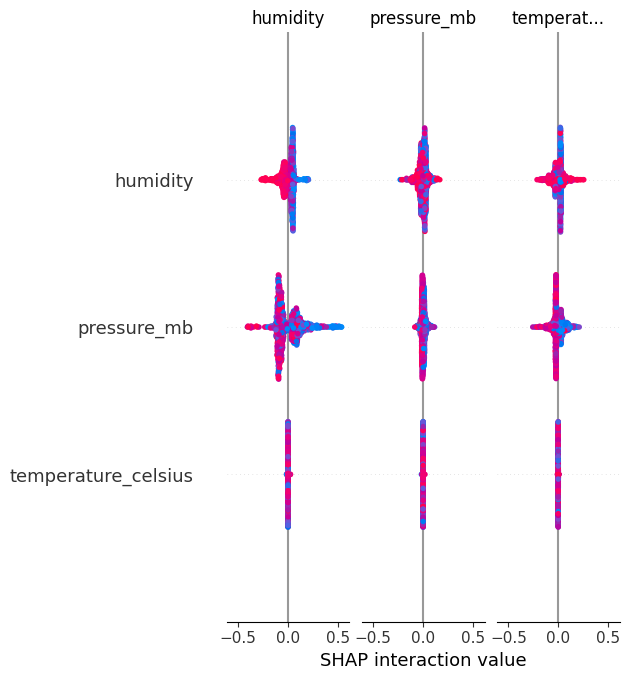

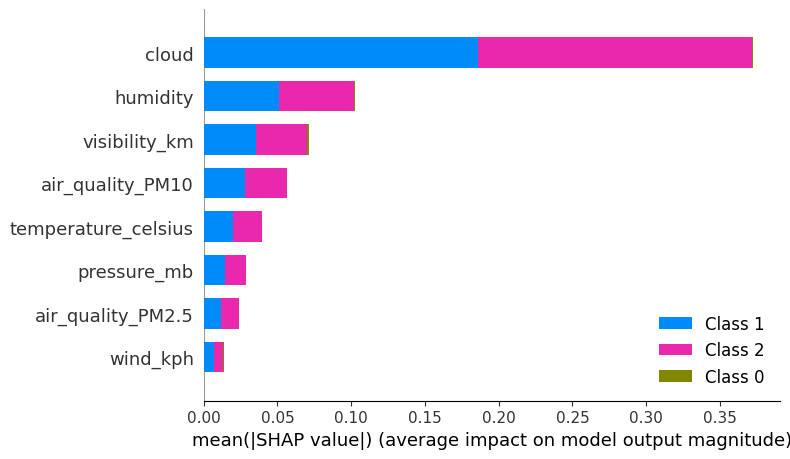

In [28]:
try:
    shap.summary_plot(
        shap_values,
        X_test_small
    )

    shap.summary_plot(
        shap_values,
        X_test_small,
        plot_type='bar'
    )
except Exception as e:
    print(f"Error generating summary plots: {e}")
    print("Summary plots could not be generated.")

# Predict on New Data

In [29]:
new_data = pd.DataFrame({
    'temperature_celsius': [31],
    'humidity': [92],
    'pressure_mb': [998],
    'cloud': [95],
    'wind_kph': [12],
    'visibility_km': [4],
    'air_quality_PM2.5': [45],
    'air_quality_PM10': [70]
})

pred = model.predict(new_data)

print("Predicted Rainfall Risk:", pred[0])



Predicted Rainfall Risk: Medium


# Force Plot

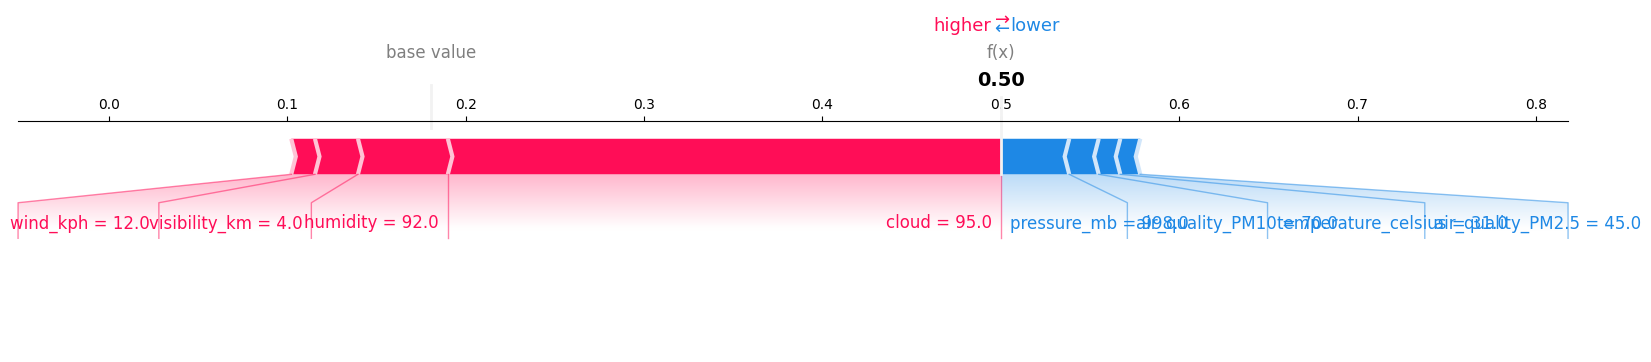

In [ ]:
import shap
import numpy as np # Import numpy for isinstance check

new_row = new_data.iloc[0:1]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(new_row)

# Calculate prediction for new_row and get the predicted class index
pred = model.predict(new_row)
new_predicted_class_idx = list(model.classes_).index(pred[0])

shap.initjs()

shap.force_plot(
    explainer.expected_value[new_predicted_class_idx],
    shap_values[0][:, new_predicted_class_idx],
    new_row.iloc[0],
    matplotlib=True 
)